# Exploração: constrained-off com dados abertos do ONS

Narrativa curta que usa o pacote `coff` (em `src/`): carrega o cache local, qualifica os registros com as regras R1–R12 e reproduz duas figuras do README. Rode antes `python scripts/rodar.py --desde 2023-01` para preencher `data/raw/`.

Parâmetro: `DESDE` controla a janela (a janela completa leva ~3 min e ~1,5 GB de memória).

In [ ]:
import sys
from pathlib import Path

RAIZ = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(RAIZ / "src"))

from coff import carregar, figuras, metricas, qualificar  # noqa: E402

DESDE = "2023_01"  # AAAA_MM
REFERENCIA = "coalesce"  # ou "referencia"


## 1. Carga (validação de schema e Δt)

In [ ]:
df, rel_carga = carregar.carregar(RAIZ / "data" / "raw", ("EOL", "UFV"), DESDE)
delta_t_h = min(rel_carga.delta_t.values()).total_seconds() / 3600
print(f"{len(df):,} registros | delta t = {delta_t_h} h | meses: {len(rel_carga.arquivos)}")


## 2. Qualificação (R1–R12) e contagens

In [ ]:
q = qualificar.qualificar(df, REFERENCIA, delta_t_h)
rel = qualificar.relatorio_qualificacao(q, REFERENCIA, delta_t_h)
rel.motivos


In [ ]:
metricas.resumo_anual(q).round(2)


## 3. Duas figuras do README

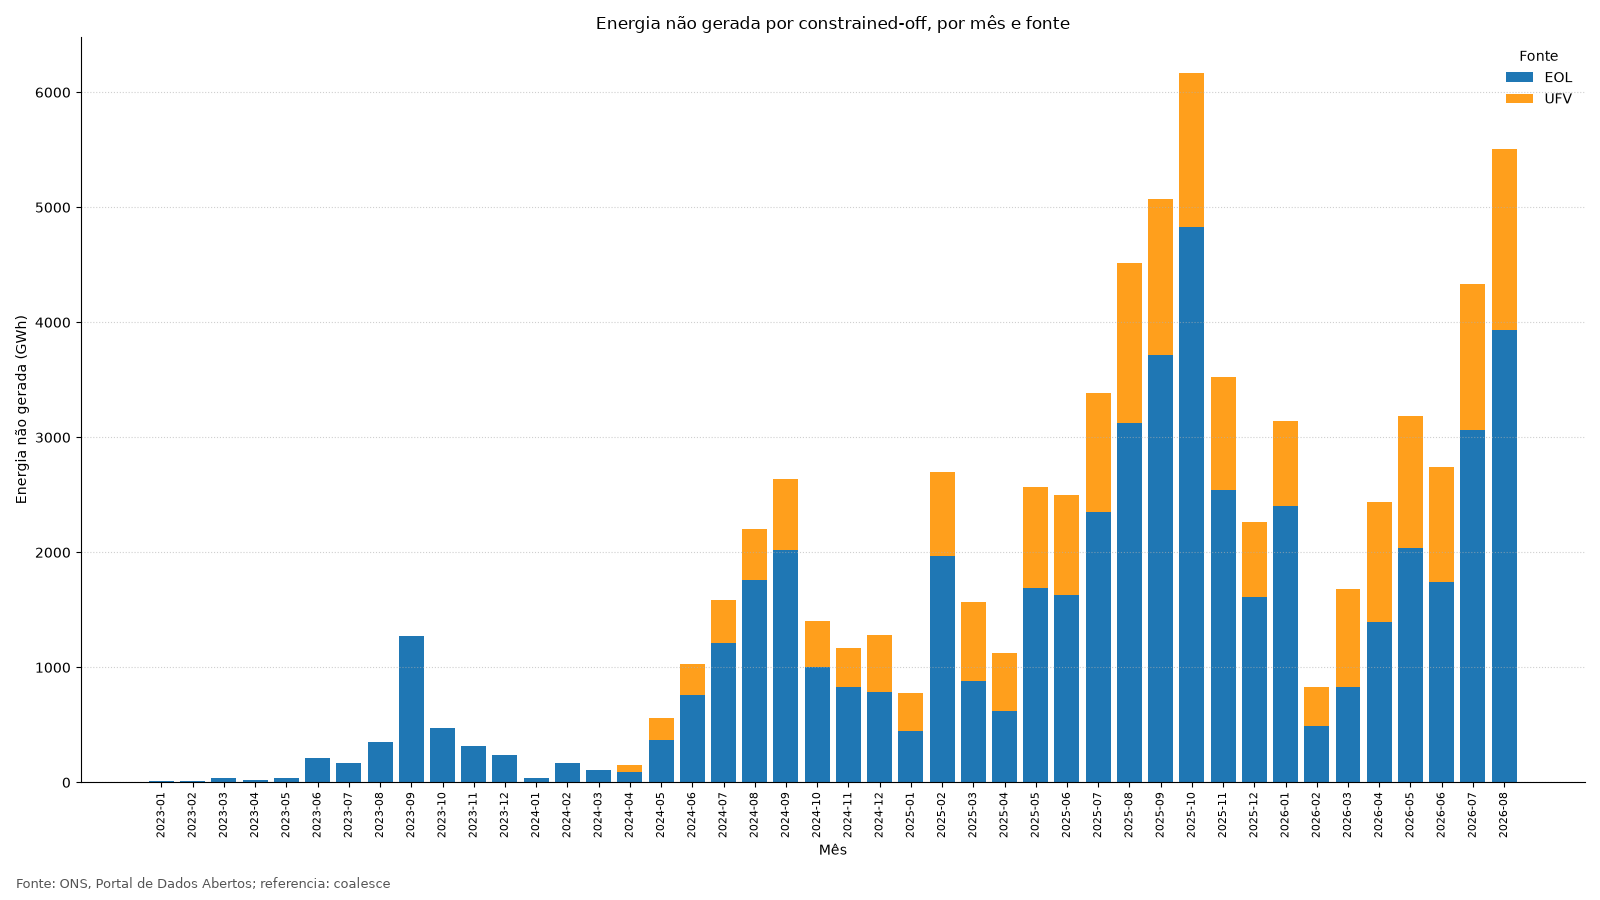

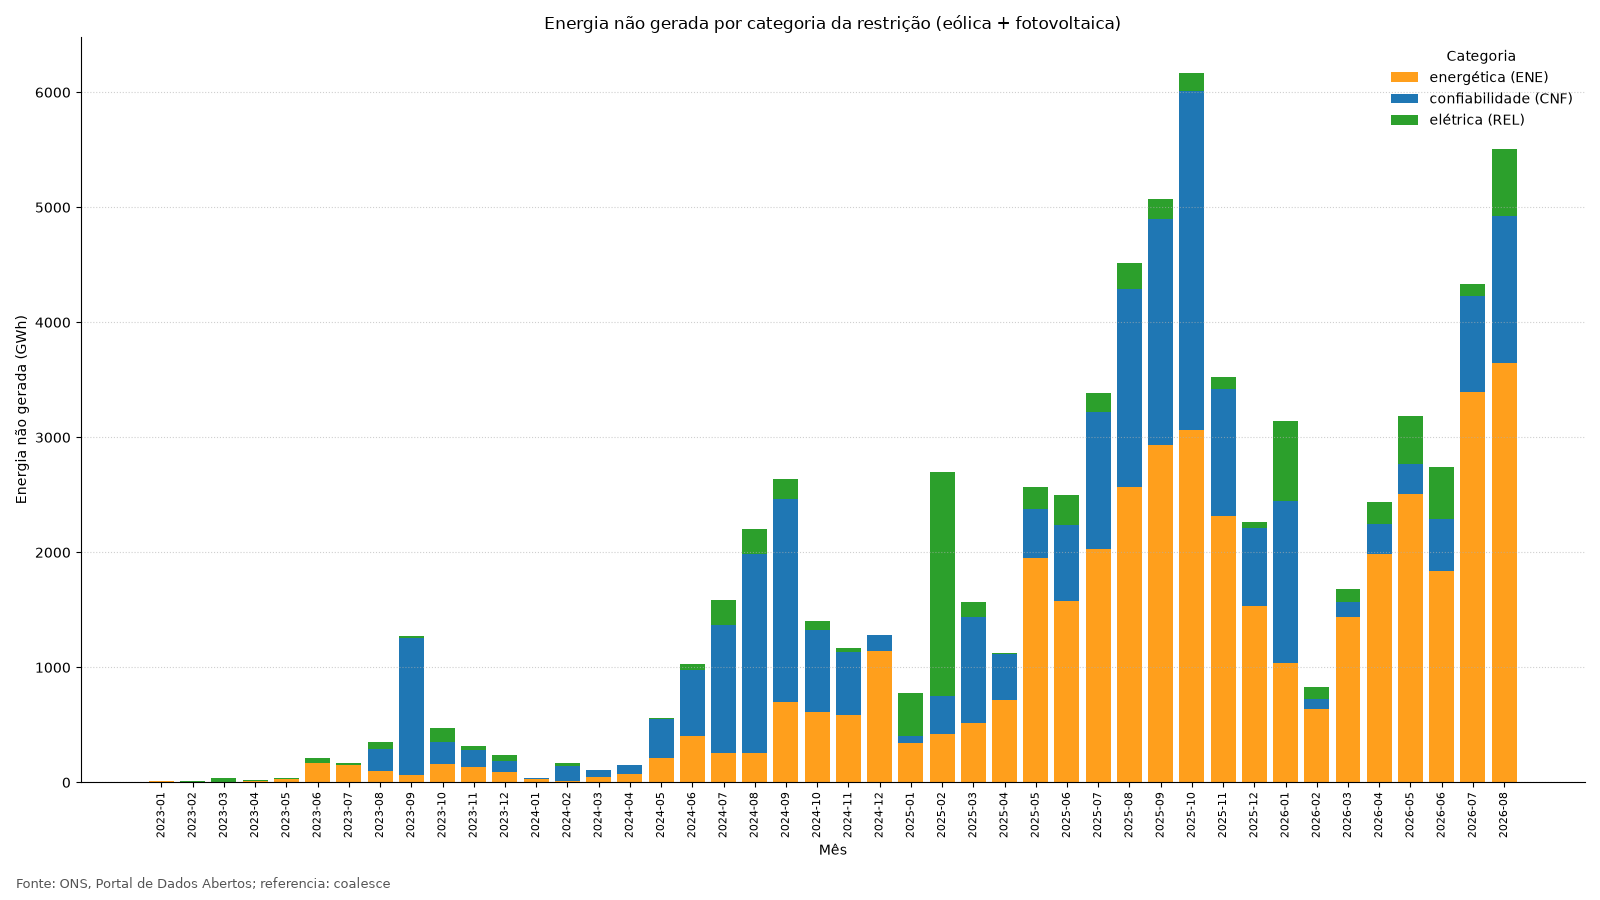

In [ ]:
from IPython.display import Image, display

rodape = f"Fonte: ONS, Portal de Dados Abertos; referencia: {REFERENCIA}"
saida = RAIZ / "data" / "processed"
saida.mkdir(parents=True, exist_ok=True)
f1 = figuras.fig1_eng_mensal(metricas.eng_por_mes(q), saida / "nb_fig1.png", rodape)
f2 = figuras.fig2_eng_por_categoria(metricas.eng_por_categoria(q), saida / "nb_fig2.png", rodape)
display(Image(filename=str(f1), width=900))
display(Image(filename=str(f2), width=900))


## 4. Sensibilidade à referência (R6)

In [ ]:
metricas.sensibilidade_referencia(q, delta_t_h).round(1)
